# Figure 1 — Seasonal Precipitation Cycle with Inter-Model Uncertainty
## Long-Term Monthly Means | Reference Period 1995–2014

**What this figure shows:**
Each panel = one basin. For every basin:
- **Observed** (thick black line + circle markers) — station long-term monthly mean
- **Shaded grey band** — min–max range across all 6 CMIP6 models (inter-model uncertainty)
- **Best single model** (solid coloured line) — top-ranked model for that basin
- **3-model ensemble** (dashed line, same colour) — top-3 basin-specific ensemble

**Scientific rationale:**
- All models share near-identical median r ≈ 0.97 (temporal sequencing captured equally well).
  The seasonal cycle plot shows this explicitly — all models track the observed shape.
- Model spread (grey band width) quantifies inter-model uncertainty per month per basin.
  Wide bands in Nov–Feb reveal that peak-rainfall simulation is the primary source of
  inter-model disagreement.
- Desert basins (AZRAQ, JAFER, HAMMAD) show narrow bands relative to the absolute values
  but large relative spread — explaining the counter-intuitive low RMSE / poor NSE pattern.
- Panels ordered by decreasing observed annual precipitation (semi-arid → Desert, left-right, top-bottom)
  so the gradient in model behaviour is immediately visible.


## 1. Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings("ignore")

# Journal-standard font settings
plt.rcParams.update({
    "font.family"       : "Arial",
    "font.size"         : 10,
    "axes.titlesize"    : 11,
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "figure.dpi"        : 150,   # screen preview
    "savefig.dpi"       : 600,   # output
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

print("Libraries loaded.")


Libraries loaded.


## 2. Configuration

In [2]:
BASE = Path(r"C:\Users\ASUS\Desktop\new.work.for.rainfall\comments")

# Input files
LTMM_WIDE_CSV    = BASE / "validation" / "single.model" / "ltmm_wide_obs_and_models.csv"
OBS_BASIN_CSV    = BASE / "basin mean from station and best approach" / "obs_basin_period_means.csv"
TABLE3_CSV       = BASE / "validation" / "single.model" / "table3_best_model_per_basin.csv"
ENS3_LTMM_CSV   = BASE / "ensemble data" / "long_term_monthly_mean" / "ltmm_ensemble_all_stations.csv"
RECOMMEND_CSV    = BASE / "validation" / "comparison" / "basin_approach_recommendation.csv"

# Output
FIG_DIR = BASE / "validation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["CMCC-CM2-SR5","CNRM-ESM2-1","EC-Earth3-Veg",
          "IPSL-CM6A-LR","MPI-ESM1-2-LR","NorESM2-MM"]

MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]

print("Configuration loaded.")
print(f"  Figures will be saved to: {FIG_DIR}")


Configuration loaded.
  Figures will be saved to: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures


## 3. Load and Prepare Data

In [3]:
# LTMM wide table: Station_ID, Basin, Month, Obs, <6 model cols>
ltmm = pd.read_csv(LTMM_WIDE_CSV)
ltmm["Basin"] = ltmm["Basin"].astype(str).str.strip()

# Aggregate to basin level: mean across stations within basin, per month
basin_ltmm = ltmm.groupby(["Basin","Month"])[["Obs"] + MODELS].mean().reset_index()

# Observed basin annual mean — for sorting panels semi-arid → desert    
obs_basin = pd.read_csv(OBS_BASIN_CSV)
obs_basin["Basin"] = obs_basin["Basin"].astype(str).str.strip()
obs_annual = dict(zip(obs_basin["Basin"], obs_basin["Annual_Mean"]))

# Best single model per basin
table3 = pd.read_csv(TABLE3_CSV)
table3 = table3[~table3["Basin"].isin(["Mean","Std Dev","Median","IQR (Q1-Q3)","IQR (Q25-Q75)"])]
table3["Basin"] = table3["Basin"].astype(str).str.strip()
best_model_dict = dict(zip(table3["Basin"], table3["Best_Model"]))

# 3-model ensemble LTMM — aggregate to basin
ens3_ltmm = pd.read_csv(ENS3_LTMM_CSV)
ens3_ltmm["Basin"] = ens3_ltmm["Basin"].astype(str).str.strip()
ens3_basin = ens3_ltmm.groupby(["Basin","Month"])["LTMM_mm_month"].mean().reset_index()

# Recommended approach per basin
recommend = pd.read_csv(RECOMMEND_CSV)
recommend["Basin"] = recommend["Basin"].astype(str).str.strip()
recommend_dict = dict(zip(recommend["Basin"], recommend["Recommended_Approach"]))

# Basin order: sort by observed annual precipitation descending (semi-arid → desert)
basins_with_data = basin_ltmm["Basin"].unique()
basin_order = sorted(
    basins_with_data,
    key=lambda b: obs_annual.get(b, 0),
    reverse=True
)
print(f"Basins ordered semi-arid → desert:")
for b in basin_order:
    print(f"  {b:<30} {obs_annual.get(b, 0):>6.1f} mm/yr")


Basins ordered semi-arid → desert:
  N.R.S.W                         445.0 mm/yr
  S.R.S.W                         349.2 mm/yr
  YARMOUK (JORDAN)                303.4 mm/yr
  JORDAN VALLY (JORDAN)           276.6 mm/yr
  D.S.R.S.W                       254.8 mm/yr
  AMMAN ZARQA (JORDAN)            222.1 mm/yr
  W. ARABA NORTH                  185.4 mm/yr
  MUJIB                           172.3 mm/yr
  HASA                            162.7 mm/yr
  JAFER                            77.0 mm/yr
  HAMMAD                           67.5 mm/yr
  AZRAQ (JORDAN)                   52.2 mm/yr


## 4. Colour Scheme

In [4]:
# Colourblind-safe palette (Wong 2011)
MODEL_COLORS = {
    "CMCC-CM2-SR5"  : "#E69F00",   # orange
    "CNRM-ESM2-1"   : "#56B4E9",   # sky blue
    "EC-Earth3-Veg" : "#009E73",   # green
    "IPSL-CM6A-LR"  : "#F0E442",   # yellow
    "MPI-ESM1-2-LR" : "#0072B2",   # deep blue
    "NorESM2-MM"    : "#CC79A7",   # purple-pink
}

# Aridity-based background tint per panel
def aridity_tint(ann_mm):
    if ann_mm >= 300: return "#F0FFF0"    # very light green  (semi-arid)
    if ann_mm >= 100: return "#FFFDF0"    # very light yellow (arid)
    return "#FFF5F0"                       # very light red    (desert)

print("Colour scheme defined (Wong 2011 colourblind-safe).")


Colour scheme defined (Wong 2011 colourblind-safe).


## 5. Build Figure 1 — Seasonal Cycle Panels

Layout: 4 rows × 3 columns (12 panels, one per basin).
Each column = one aridity tier (semi-arid | Arid | desert).
Panel order within each column: decreasing annual precipitation.




Saved: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures\Figure1_seasonal_cycle.png
Saved: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\validation\figures\Figure1_seasonal_cycle.pdf


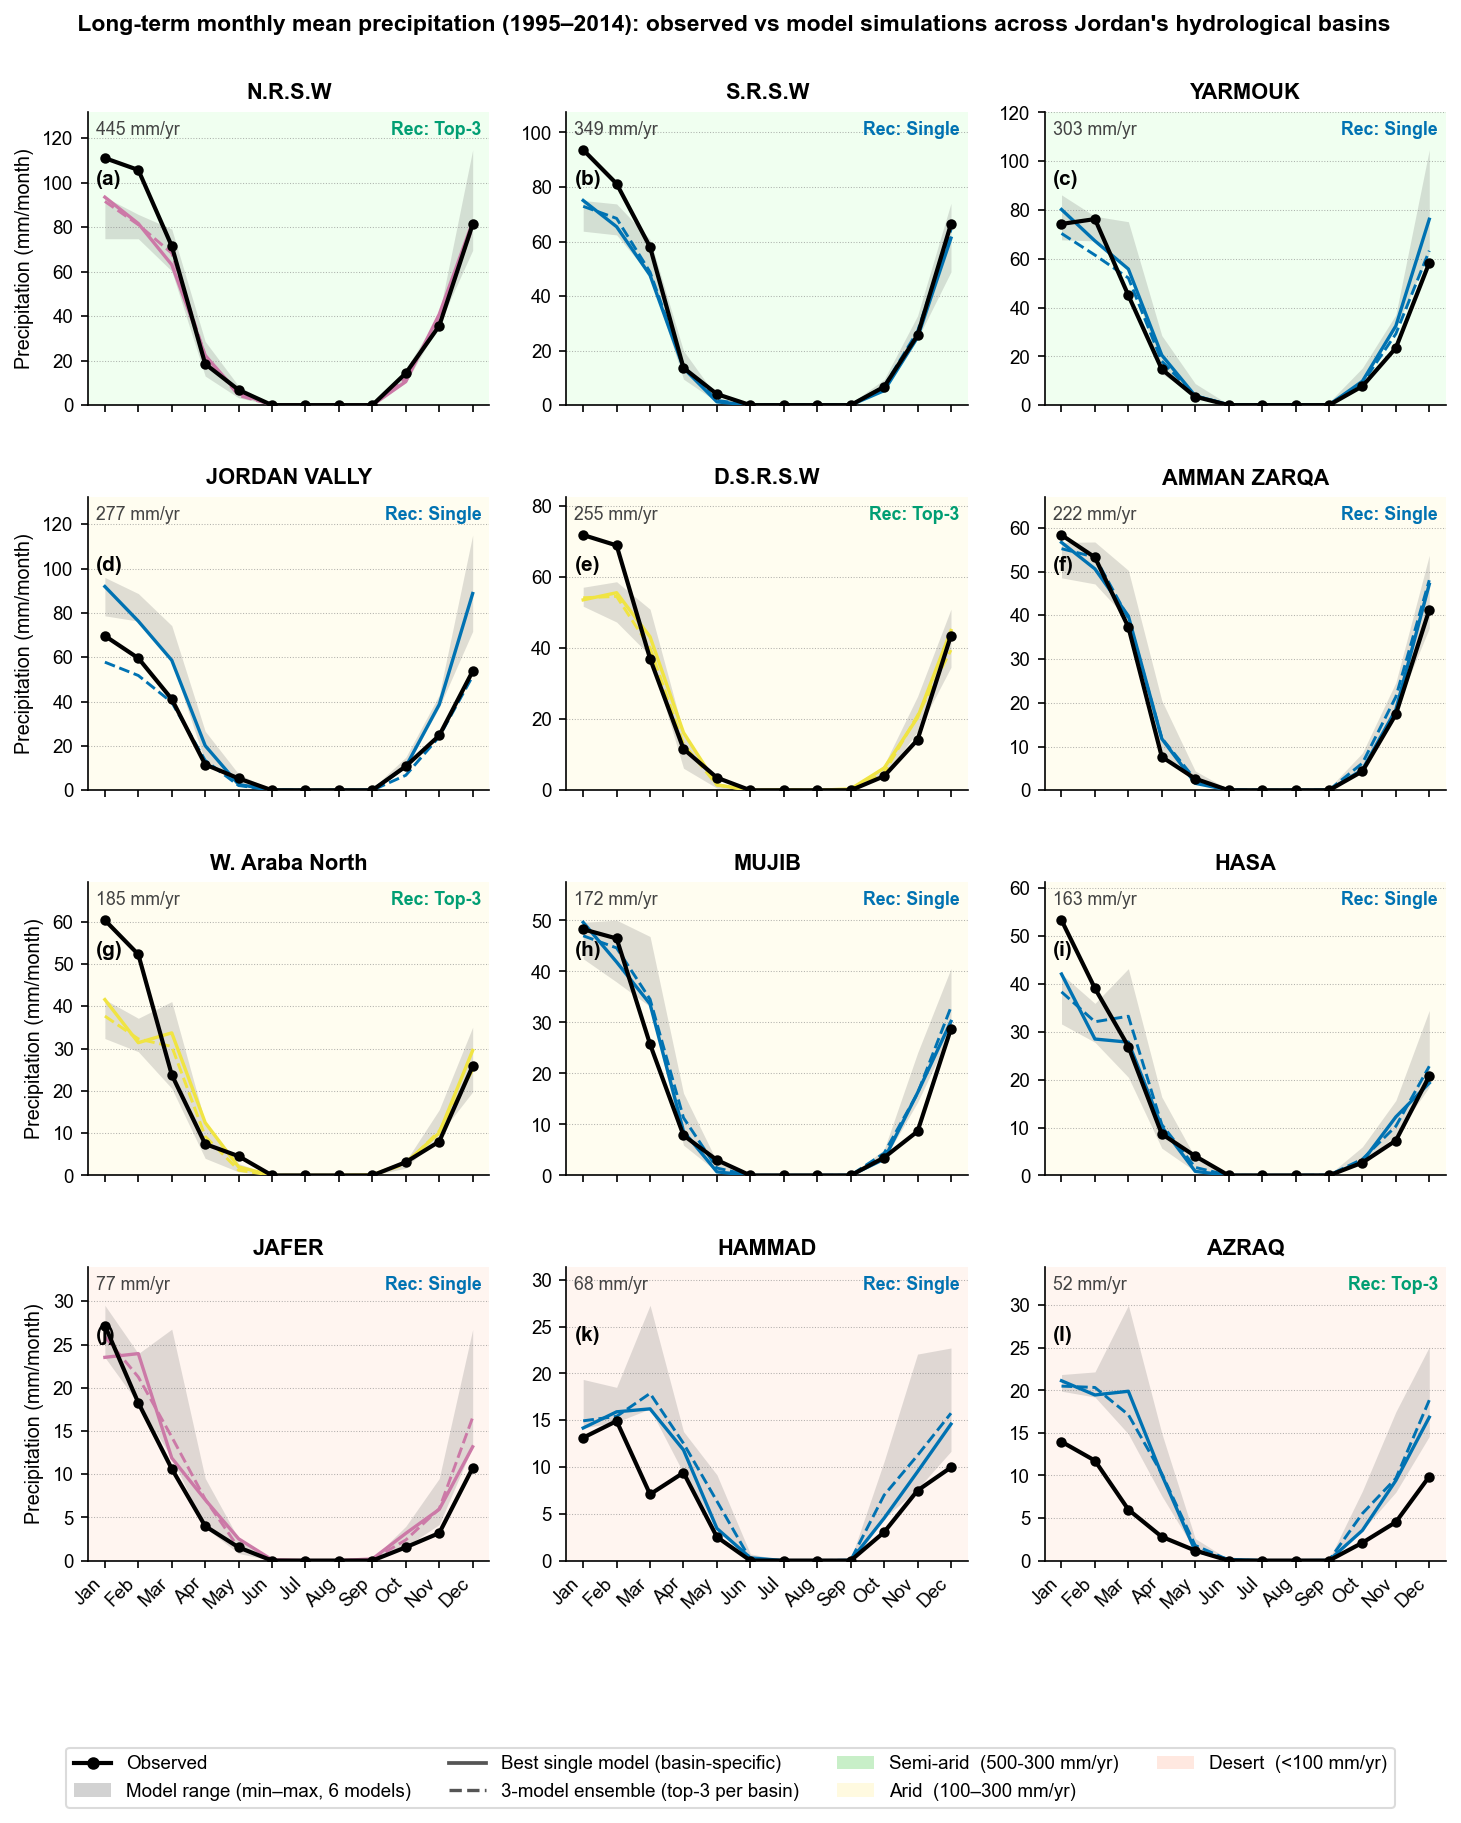

Figure 1 complete.


In [7]:
# ── Layout ────────────────────────────────────────────────────────────────────
N_COLS = 3
N_ROWS = 4
# Wider and taller to give each panel enough room for labels/annotations
# 250 mm wide x 310 mm tall gives generous spacing without crowding
FIG_W_IN = 9.84   # ~250 mm
FIG_H_IN = 12.20  # ~310 mm

months = np.arange(1, 13)

fig, axes = plt.subplots(N_ROWS, N_COLS,
                          figsize=(FIG_W_IN, FIG_H_IN),
                          sharey=False, sharex=True)
axes_flat = axes.flatten()

panel_labels = [chr(ord("a") + i) for i in range(12)]  # a, b, c, …, l

for panel_idx, basin in enumerate(basin_order):
    ax = axes_flat[panel_idx]
    bdf = basin_ltmm[basin_ltmm["Basin"] == basin].sort_values("Month")
    ann = obs_annual.get(basin, np.nan)

    if bdf.empty:
        ax.set_visible(False)
        continue

    # ── Panel background tint by aridity ─────────────────────────────────────
    ax.set_facecolor(aridity_tint(ann))

    months_arr = bdf["Month"].values

    # ── Inter-model uncertainty band (min–max across 6 models) ───────────────
    model_vals = bdf[MODELS].values           # shape (12, 6)
    band_min   = np.nanmin(model_vals, axis=1)
    band_max   = np.nanmax(model_vals, axis=1)
    ax.fill_between(months_arr, band_min, band_max,
                    color="grey", alpha=0.25, linewidth=0,
                    label="Model range (min–max)")

    # ── Best single model line ────────────────────────────────────────────────
    best_model = best_model_dict.get(basin)
    if best_model and best_model in bdf.columns:
        best_vals = bdf[best_model].values
        best_color = MODEL_COLORS.get(best_model, "#333333")
        ax.plot(months_arr, best_vals,
                color=best_color, linewidth=1.6,
                linestyle="-", zorder=4,
                label=f"Best model ({best_model})")

    # ── 3-model ensemble ─────────────────────────────────────────────────────
    ens3_b = ens3_basin[ens3_basin["Basin"] == basin].sort_values("Month")
    if not ens3_b.empty:
        ens3_vals = ens3_b["LTMM_mm_month"].values
        ax.plot(months_arr[:len(ens3_vals)], ens3_vals,
                color=best_color if best_model else "#444444",
                linewidth=1.4, linestyle="--", zorder=3,
                label="3-model ensemble")

    # ── Observed ─────────────────────────────────────────────────────────────
    obs_vals = bdf["Obs"].values
    ax.plot(months_arr, obs_vals,
            color="black", linewidth=2.0,
            linestyle="-", marker="o", markersize=4,
            zorder=5, label="Observed")

    # ── Approach indicator (top-right) ───────────────────────────────────────
    appr = recommend_dict.get(basin, "Best Single Model")
    appr_short = {"Best Single Model": "Single", "3-Model Ensemble": "Top-3", "6-Model Ensemble": "Ens-6"}
    appr_label = appr_short.get(appr, appr)
    appr_color = {"Best Single Model": "#0072B2", "3-Model Ensemble": "#009E73", "6-Model Ensemble": "#E69F00"}
    ax.text(0.98, 0.97, f"Rec: {appr_label}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color=appr_color.get(appr, "black"),
            fontweight="bold")

    # ── Observed annual mean annotation (top-left) ────────────────────────────
    # Placed at y=0.97; panel label placed lower at y=0.80 to prevent stacking
    ax.text(0.02, 0.97, f"{ann:.0f} mm/yr",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=8.5, color="#444444")

    # ── Panel label (a, b, c …) — clearly below mm/yr text ───────────────────
    ax.text(0.02, 0.80, f"({panel_labels[panel_idx]})",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=10, fontweight="bold", color="black")

    # ── Basin name as panel title ─────────────────────────────────────────────
    bname = basin.replace(" (JORDAN)", "").replace("W. ARABA NORTH", "W. Araba North")
    ax.set_title(bname, fontsize=10.5, fontweight="bold", pad=6)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(range(1, 13))
    # Only show x-tick labels on the bottom row; shared x-axis hides others
    ax.set_xticklabels(MONTH_ABBR, fontsize=9, rotation=45, ha="right")
    ax.tick_params(axis='x', pad=3)
    ax.yaxis.set_tick_params(labelsize=9)
    y_max = max(np.nanmax(obs_vals), np.nanmax(band_max)) * 1.15
    ax.set_ylim(bottom=0, top=max(y_max, 5))
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="grey", alpha=0.6)
    ax.set_axisbelow(True)

    # Y-label only on left column
    if panel_idx % N_COLS == 0:
        ax.set_ylabel("Precipitation (mm/month)", fontsize=9.5, labelpad=4)

# ── Hide unused panels ────────────────────────────────────────────────────────
for idx in range(len(basin_order), N_ROWS * N_COLS):
    axes_flat[idx].set_visible(False)

# ── Shared legend at bottom ───────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0],[0], color="black", lw=2.0, marker="o",
               markersize=5, label="Observed"),
    mpatches.Patch(facecolor="grey", alpha=0.35,
                   label="Model range (min\u2013max, 6 models)"),
    plt.Line2D([0],[0], color="#555555", lw=1.8, ls="-",
               label="Best single model (basin-specific)"),
    plt.Line2D([0],[0], color="#555555", lw=1.6, ls="--",
               label="3-model ensemble (top-3 per basin)"),
    mpatches.Patch(facecolor="#C8EFC8", label="Semi-arid  (500-300 mm/yr)"),
    mpatches.Patch(facecolor="#FFFAE0", label="Arid  (100\u2013300 mm/yr)"),
    mpatches.Patch(facecolor="#FFE8E0", label="Desert  (<100 mm/yr)"),
]

# Apply tight_layout first so subplots are positioned, then place legend below
plt.tight_layout(rect=[0, 0.11, 1, 0.97], h_pad=2.5, w_pad=1.5)

fig.legend(handles=legend_elements, loc="lower center",
           ncol=4, fontsize=9,
           frameon=True, edgecolor="lightgrey",
           bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    " Long-term monthly mean precipitation (1995\u20132014): "
    "observed vs model simulations across Jordan's hydrological basins",
    fontsize=11, fontweight="bold", y=0.995
)

# ── Save ─────────────────────────────────────────────────────────────────────
for fmt in ["png", "pdf"]:
    out_path = FIG_DIR / f"Figure1_seasonal_cycle.{fmt}"
    fig.savefig(out_path, dpi=600, bbox_inches="tight",
                format=fmt, facecolor="white")
    print(f"Saved: {out_path}")

plt.show()
print("Figure 1 complete.")


## 6. Supplementary — Inter-Model Spread Statistics per Basin

Quantifies the uncertainty band: for each basin, compute the mean monthly
inter-model range (max−min across 6 models) and the coefficient of variation
of model spread.


In [6]:
spread_rows = []
for basin in basin_order:
    bdf = basin_ltmm[basin_ltmm["Basin"] == basin].sort_values("Month")
    if bdf.empty:
        continue
    model_vals = bdf[MODELS].values
    obs_vals   = bdf["Obs"].values
    band_range = np.nanmax(model_vals, axis=1) - np.nanmin(model_vals, axis=1)
    spread_rows.append({
        "Basin"            : basin,
        "Obs_Annual_mm"    : round(obs_annual.get(basin, np.nan), 1),
        "Mean_Range_mm"    : round(np.mean(band_range), 2),
        "Max_Range_mm"     : round(np.max(band_range), 2),
        "Max_Range_Month"  : MONTH_ABBR[np.argmax(band_range)],
        "Spread_CV_pct"    : round(np.std([np.nanmean(model_vals[:,i]) for i in range(6)])
                                   / np.nanmean(obs_vals) * 100, 1),
    })

spread_df = pd.DataFrame(spread_rows)
spread_df.to_csv(FIG_DIR / "Fig1_model_spread_stats.csv", index=False)
print("Model spread statistics:")
print(spread_df.to_string(index=False))


Model spread statistics:
                Basin  Obs_Annual_mm  Mean_Range_mm  Max_Range_mm Max_Range_Month  Spread_CV_pct
              N.R.S.W          445.0          10.51         45.17             Dec            3.0
              S.R.S.W          349.2           7.24         25.15             Dec            2.2
     YARMOUK (JORDAN)          303.4          10.28         42.53             Dec            4.2
JORDAN VALLY (JORDAN)          276.6           9.95         43.44             Dec            4.4
            D.S.R.S.W          254.8           6.01         16.37             Dec            3.3
 AMMAN ZARQA (JORDAN)          222.1           5.94         16.67             Dec            3.1
       W. ARABA NORTH          185.4           5.94         20.52             Mar            5.0
                MUJIB          172.3           5.81         13.75             Mar            5.6
                 HASA          162.7           6.82         22.68             Mar            5.5
     